# Plot time lag when SIC>15% in satellite data

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import re

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import matplotlib as mpl

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:39179")
client

<Client: 'tcp://127.0.0.1:39179' processes=8 threads=32, memory=123.95 GiB>

In [3]:
years = np.arange(2014,2021,1)

In [4]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

In [5]:
sic_ancillary =  xr.open_dataset(sic_files[0])

In [6]:
def find_ice_onset_doy(sic, threshold=15, duration=5):
    # Convert to binary mask: 1 if SIC >= threshold, else 0
    ice_mask = sic >= threshold

    # Rolling sum over time to find 5-day periods over threshold
    ice_rolling = ice_mask.rolling(time=duration, center=False).sum()

    # First time index where the rolling sum equals duration (i.e., 5 consecutive days over threshold)
    condition_met = (ice_rolling >= duration)

    # Find the first time index this condition is True
    def first_true_doy(x, time_coords):
        if not np.any(x):
            return np.nan
        first_index = np.argmax(x)
        return pd.to_datetime(time_coords[first_index]).dayofyear

    # Apply over grid cells
    doy = xr.apply_ufunc(
        first_true_doy,
        condition_met,
        condition_met['time'],
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[]],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
    )

    return doy

In [7]:
def filter_files(files, year):
    year = str(year)
    filtered = []

    for f in files:
        # extract YYYYMMDD from filename
        m = re.search(r'(\d{8})', f)
        if m:
            date = pd.to_datetime(m.group(1), format="%Y%m%d")
            if (str(date.year) == year) and (date.month >= 9) and (date.month <= 12):
                filtered.append(f)

    return filtered

In [8]:
def process_ice_onset_year(year, sic_files, output_dir):
    """
    Create and save a dataset containing the normalized ice onset DOY 
    for a given year using NSIDC SIC CDR data.

    Parameters
    ----------
    year : int
        The year to process.
    sic_files : list of str
        List of all SIC file paths to filter from.
    output_dir : str
        Directory where the yearly output NetCDF will be saved.

    Returns
    -------
    str : Path to the saved file.
    """

    # --- 1. Open data for this year ---
    files_yr = filter_files(sic_files, year)
    ds = xr.open_mfdataset(files_yr, combine='nested', concat_dim='time')

    # subset like your example
    sic = ds.isel(x=slice(60,100), y=slice(180,260)).cdr_seaice_conc.load()

    # --- 2. Add DOY coordinate ---
    sic = sic.assign_coords(DOY=("time", sic['time'].dt.dayofyear.values))

    # --- 3. Determine minimum SIC date ---
    sic_avg = sic.mean(dim=['x', 'y'])
    min_idx = sic_avg.idxmin(dim="time")
    min_doy = sic['DOY'].sel(time=min_idx).item()
    print(f"{year}: Minimum SIC DOY = {min_doy}")

    # --- 4. Compute ice onset DOY ---
    doy_onset = find_ice_onset_doy(sic * 100, duration=3)

    # --- 5. Find plume reference point ---
    plume_pt = doy_onset.sel(x=-2.25e6, y=0, method='nearest')
    plume_doy = plume_pt.values

    # --- 6. Normalize by plume DOY ---
    doy_onset_normalized = doy_onset - plume_doy

    # --- 7. mask out SIC>15% on sea ice min date
    doy_onset_masked = doy_onset_normalized.where(sic.sel(time=min_idx)<0.15)

    # --- 8. Build output dataset ---
    out = xr.Dataset(
        {
            "doy_onset": doy_onset_masked,
            "doy_onset_normalized": doy_onset_normalized,
            "min_SIC_DOY": xr.DataArray(min_doy),
            "plume_doy": xr.DataArray(plume_doy),
        },
        coords={
            "x": doy_onset.x,
            "y": doy_onset.y,
        }
    )

    # --- 8. Save ---
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"sat_sic_nsidc_doy_onset_{year}_ice_masked.nc")
    out.to_netcdf(output_path)

    return output_path

In [15]:
output_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data"

for yr in range(2010, 2025):
# for yr in range(2010, 2014):
    print(f"Processing {yr}...")
    path = process_ice_onset_year(yr, sic_files, output_dir)
    print(f"Saved: {path}\n")

Processing 2010...
2010: Minimum SIC DOY = 253
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_2010_ice_masked.nc

Processing 2011...
2011: Minimum SIC DOY = 249
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_2011_ice_masked.nc

Processing 2012...
2012: Minimum SIC DOY = 254
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_2012_ice_masked.nc

Processing 2013...
2013: Minimum SIC DOY = 244
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_2013_ice_masked.nc

Processing 2014...
2014: Minimum SIC DOY = 252
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_2014_ice_masked.nc

Processing 2015...
2015: Minimum SIC DOY = 245
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_2015_ice_masked.nc

Processing 2016...
2016: Minimum SIC DOY = 269
Saved: /home/jpluser/efs-mount-point/mzahn/satellite_data/s

***

In [10]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*facecolor will have no effect as it has been defined as \"never\".*"
)

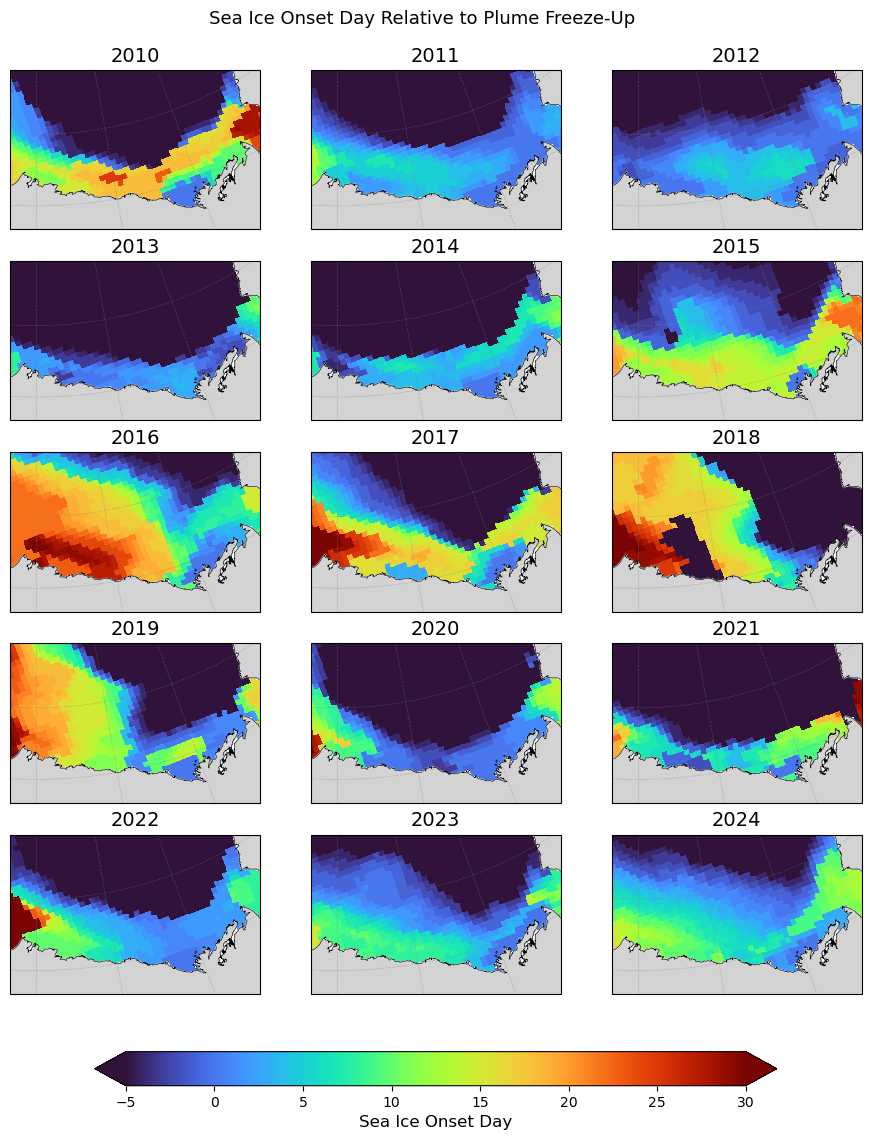

In [12]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

# ---- Projection setup (once) ----
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# ---- Years ----
years = list(range(2010, 2025))

# ---- Create multipanel figure ----
fig, axs = plt.subplots(
    5, 3,
    figsize=(11, 15),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}
)

axs = axs.flatten()

# Index of bottom-left subplot (row 4, col 0 in 5×3) = index 12
idx_bottom_left = 4 * 3 + 0  # = 12

# ---- Loop over years ----
for i, yr in enumerate(years):

    ax = axs[i]

    # Load dataset
    ds_path = f"/home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_{yr}.nc"
    ds = xr.open_dataset(ds_path)

    doy_onset = ds["doy_onset"]
    doy_onset_normalized = ds["doy_onset_normalized"]

    # ---- Compute lon/lat from NSIDC grid ----
    x = doy_onset["x"].values
    y = doy_onset["y"].values
    xx, yy = np.meshgrid(x, y)
    lon, lat = transformer.transform(xx, yy)

    doy_onset = doy_onset.assign_coords(lon=(("y", "x"), lon),
                                        lat=(("y", "x"), lat))

    # ---- Plot panel ----
    pcm = ax.pcolormesh(
        doy_onset.lon, doy_onset.lat, doy_onset_normalized,
        transform=ccrs.PlateCarree(),
        cmap="turbo",
        vmin=-5, vmax=30
    )

    # Map extent (Beaufort Sea)
    ax.set_extent([-158, -128, 69, 74], crs=ccrs.PlateCarree())

    # Land + coastlines
    land = cfeature.NaturalEarthFeature('physical', 'land', '50m')
    ax.add_feature(land, color='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')

    # ---- Add faint gridlines ----
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # no labels for most subplots
        linewidth=0.5,
        color='gray',
        alpha=0.4,
        linestyle='--'
    )
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.FixedLocator([-135, -145, -155])
    gl.ylocator = mticker.FixedLocator([70, 73])

    ax.set_title(f"{yr}", fontsize=14)

# ---- Shared colorbar ----
cbar = fig.colorbar(
    pcm,
    ax=axs,
    orientation='horizontal',
    shrink=0.8,
    pad=0.05,
    extend='both'
)
cbar.set_label("Sea Ice Onset Day", fontsize=12)

fig.suptitle("Sea Ice Onset Day Relative to Plume Freeze-Up", fontsize=13, y=0.92)

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/DOY_ice_onset_satellite.png',
            dpi=300, bbox_inches='tight')

# plt.show()

### Filter out SIC > 15% on sea ice min date

Text(0.5, 0.92, 'Sea Ice Onset Day Relative to Plume Freeze-Up')

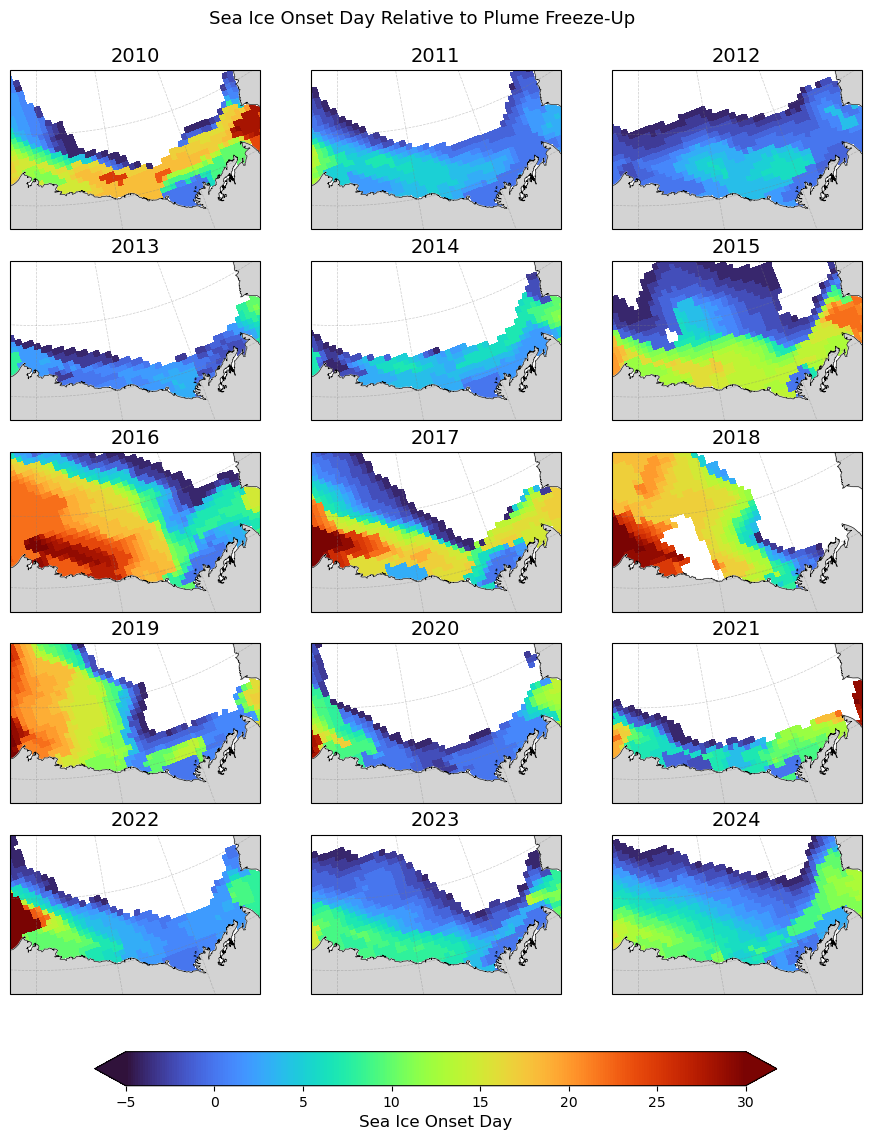

In [54]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

# ---- Projection setup (once) ----
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# ---- Years ----
years = list(range(2010, 2025))

# ---- Create multipanel figure ----
fig, axs = plt.subplots(
    5, 3,
    figsize=(11, 15),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}
)

axs = axs.flatten()

# Index of bottom-left subplot (row 4, col 0 in 5×3) = index 12
idx_bottom_left = 4 * 3 + 0  # = 12

# ---- Loop over years ----
for i, yr in enumerate(years):

    ax = axs[i]

    # Load dataset
    ds_path = f"/home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_{yr}_ice_masked.nc"
    ds = xr.open_dataset(ds_path)

    doy_onset = ds["doy_onset"]
    doy_onset_normalized = ds["doy_onset_normalized"]

    # ---- Compute lon/lat from NSIDC grid ----
    x = doy_onset["x"].values
    y = doy_onset["y"].values
    xx, yy = np.meshgrid(x, y)
    lon, lat = transformer.transform(xx, yy)

    doy_onset = doy_onset.assign_coords(lon=(("y", "x"), lon),
                                        lat=(("y", "x"), lat))

    # ---- Plot panel ----
    pcm = ax.pcolormesh(
        doy_onset.lon, doy_onset.lat, doy_onset_normalized.where(doy_onset_normalized>-5),
        transform=ccrs.PlateCarree(),
        cmap="turbo",
        vmin=-5, vmax=30
    )

    # Map extent (Beaufort Sea)
    ax.set_extent([-158, -128, 69, 74], crs=ccrs.PlateCarree())

    # Land + coastlines
    land = cfeature.NaturalEarthFeature('physical', 'land', '50m')
    ax.add_feature(land, color='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')

    # ---- Add faint gridlines ----
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # no labels for most subplots
        linewidth=0.5,
        color='gray',
        alpha=0.4,
        linestyle='--'
    )
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.FixedLocator([-135, -145, -155])
    gl.ylocator = mticker.FixedLocator([70, 73])

    ax.set_title(f"{yr}", fontsize=14)

# ---- Shared colorbar ----
cbar = fig.colorbar(
    pcm,
    ax=axs,
    orientation='horizontal',
    shrink=0.8,
    pad=0.05,
    extend='both'
)
cbar.set_label("Sea Ice Onset Day", fontsize=12)

fig.suptitle("Sea Ice Onset Day Relative to Plume Freeze-Up", fontsize=13, y=0.92)

# fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/DOY_ice_onset_satellite.png',
#             dpi=300, bbox_inches='tight')

# plt.show()

### Plot only model years

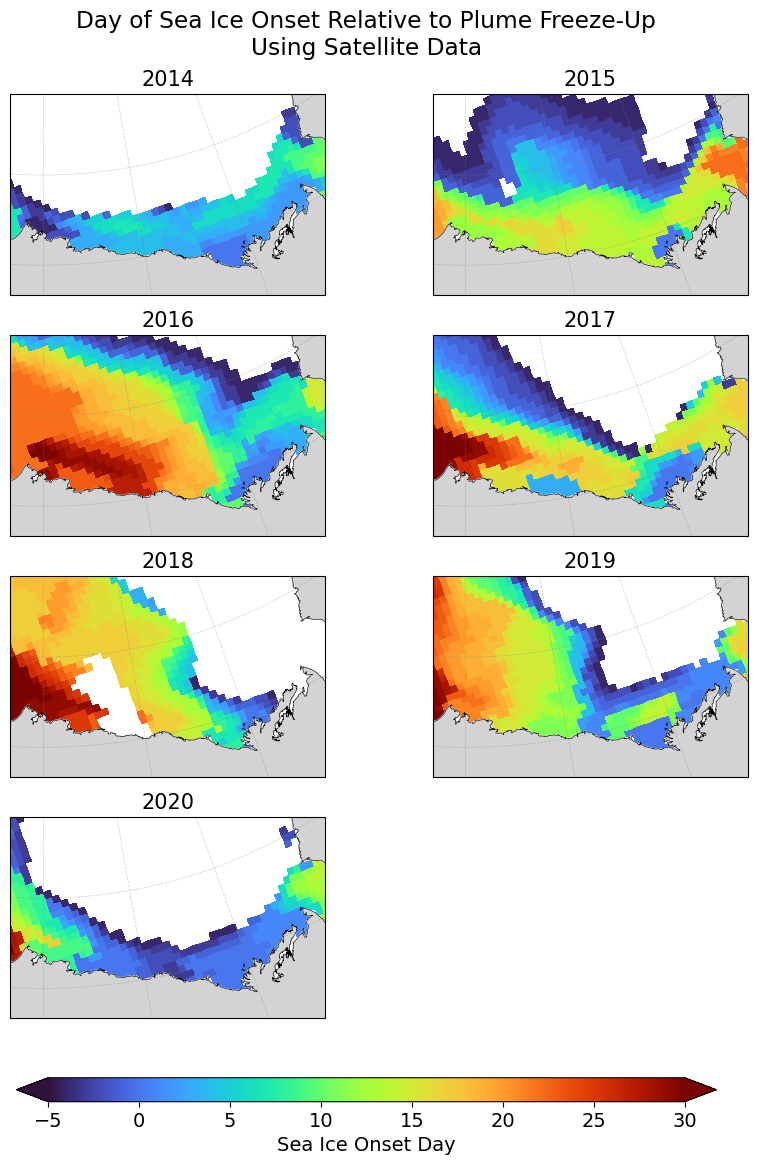

In [12]:
plt.rcParams['font.size'] = 14

# ---- Projection setup ----
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# ---- Years to plot ----
years = np.arange(2014, 2021)
n_years = len(years)

# ---- Multipanel 4×2 figure ----
fig, axs = plt.subplots(
    nrows=4, ncols=2,
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}
)
axs = axs.flatten()

vmin, vmax = -5, 30

for i, yr in enumerate(years):
    ax = axs[i]

    # --- Load dataset ---
    ds_path = f"/home/jpluser/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_doy_onset_{yr}_ice_masked.nc"
    ds = xr.open_dataset(ds_path)

    doy_onset = ds["doy_onset"]
    doy_onset_normalized = ds["doy_onset_normalized"]

    # --- Convert NSIDC stereographic x/y to lon/lat ---
    x = doy_onset["x"].values
    y = doy_onset["y"].values
    xx, yy = np.meshgrid(x, y)
    lon, lat = transformer.transform(xx, yy)

    doy_onset = doy_onset.assign_coords(
        lon=(("y", "x"), lon),
        lat=(("y", "x"), lat)
    )

    # --- Plot ---
    pcm = ax.pcolormesh(
        doy_onset.lon,
        doy_onset.lat,
        doy_onset_normalized.where(doy_onset_normalized > -5),
        transform=ccrs.PlateCarree(),
        cmap="turbo",
        vmin=vmin, vmax=vmax
    )

    # --- Beaufort Sea extent ---
    ax.set_extent([-158, -128, 69, 74], crs=ccrs.PlateCarree())

    # --- Land + coast ---
    land = cfeature.NaturalEarthFeature('physical', 'land', '50m')
    ax.add_feature(land, color='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')

    # --- Gridlines ---
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.5, color='gray', alpha=0.4, linestyle='--'
    )
    gl.xlocator = mticker.FixedLocator([-155, -145, -135])
    gl.ylocator = mticker.FixedLocator([67, 70, 73])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    ax.set_title(f"{yr}", fontsize=15)

# ---- Hide unused subplots, if any ----
if n_years < len(axs):
    for ax in axs[n_years:]:
        ax.axis("off")

# ---- Shared horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax, cmap="turbo", norm=norm,
    orientation="horizontal", extend="both"
)
cbar.set_label("Sea Ice Onset Day", fontsize=14)

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/DOY_ice_onset_satellite.png',
            dpi=300, bbox_inches='tight')

fig.suptitle("Day of Sea Ice Onset Relative to Plume Freeze-Up\nUsing Satellite Data", y=0.95);